## STEP 1: Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

## STEP 2: Load Dataset

In [13]:
df = pd.read_csv(r"E:\EDA\loan_default\data\Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


🎯 Questions

Is target present?

Any obvious wrong values?

## STEP 3: Basic Data Overview

In [14]:
df.shape

(148670, 34)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [16]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


🎯 Observe

Numeric vs categorical columns

Income / loan_amount ranges

Any suspicious values (0 income, negative values)

## STEP 4: Missing Value Analysis

In [22]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                           0
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [20]:
df['income'].fillna(df['income'].median(), inplace=True)
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)
df['loan_purpose'].fillna(df['loan_purpose'].mode(), inplace=True)


C:\Users\SonuKumar\AppData\Local\Temp\ipykernel_25244\2879998338.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['income'].fillna(df['income'].median(), inplace=True)
C:\Users\SonuKumar\AppData\Local\Temp\ipykernel_25244\2879998338.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

📌 Interview line

“Median is used because income and credit score are skewed.”

## STEP 5: Target Variable Analysis (Default)

In [26]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [27]:
df['Status'].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

## STEP 5B: Understand What Status Means

In Kaggle loan datasets, usually:

Status Value	Meaning

0	Non-default / Approved / Paid

1	Default / Rejected / Failed

In [28]:
df['Status'].unique

<bound method Series.unique of 0         1
1         1
2         0
3         0
4         0
         ..
148665    0
148666    0
148667    0
148668    0
148669    0
Name: Status, Length: 148670, dtype: int64>

📌 Interview-style explanation

“The Status column represents the loan outcome and is used as the target variable for default analysis.”

## STEP 5C: Visualize Target Distribution

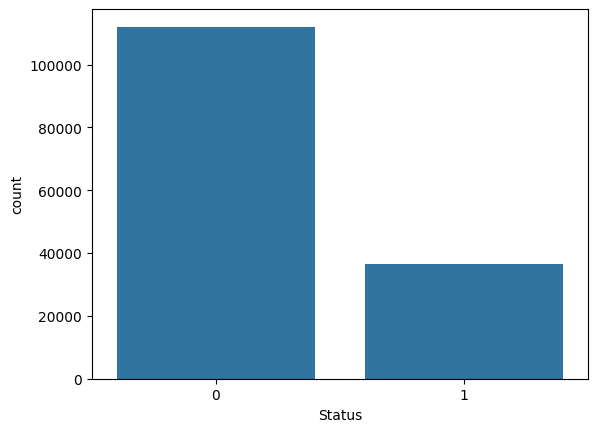

<Figure size 500x300 with 0 Axes>

In [35]:
sns.countplot(x='Status', data=df)
plt.figure(figsize=(5,3))
plt.show()

## OPTIONAL (Make It Clearer)

Rename column for clarity (recommended):

In [36]:
df.rename(columns={'Status': 'default'}, inplace=True)

In [37]:
df.value_counts()

ID      year  loan_limit  Gender             approv_in_adv  loan_type  loan_purpose  Credit_Worthiness  open_credit  business_or_commercial  loan_amount  rate_of_interest  Interest_rate_spread  Upfront_charges  term   Neg_ammortization  interest_only  lump_sum_payment  property_value  construction_type  occupancy_type  Secured_by  total_units  income   credit_type  Credit_Score  co-applicant_credit_type  age    submission_of_application  LTV        Region   Security_Type  default  dtir1
24892   2019  cf          Male               pre            type1      p1            l1                 nopc         nob/c                   406500       4.560             0.2000                595.00           360.0  neg_amm            not_int        not_lpsm          508000.0        sb                 pr              home        1U           9480.0   EXP          834           CIB                       35-44  to_inst                    80.019685  south    direct         0        46.0     1
24894   201

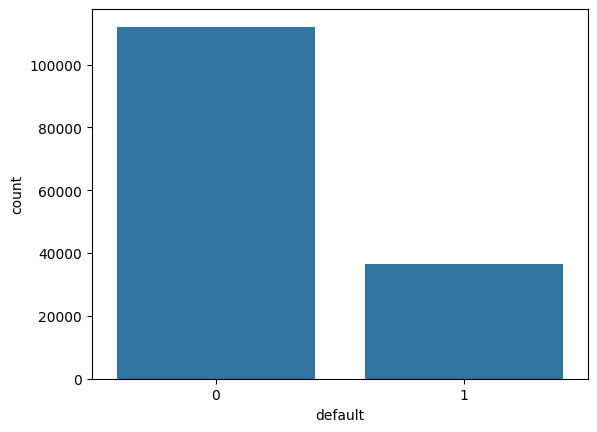

<Figure size 500x300 with 0 Axes>

In [39]:
sns.countplot(x='default', data=df)
plt.figure(figsize=(5,3))
plt.show()

Why This Happened (Important Learning)

✔ Kaggle datasets never use consistent target names

✔ You must identify target logically, not blindly

✔ This is real EDA skill, not a mistake

## STEP 6: Univariate Analysis (Numerical)

### Income Distribution

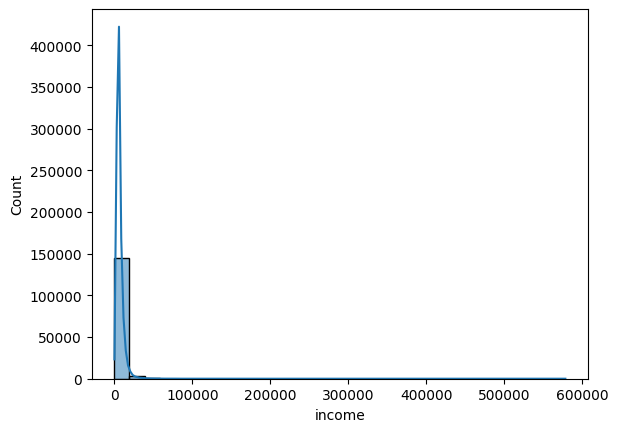

<Figure size 500x300 with 0 Axes>

In [47]:
sns.histplot(df['income'], bins=30, kde=True)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Income is right-skewed → few high earners

### Loan Amount

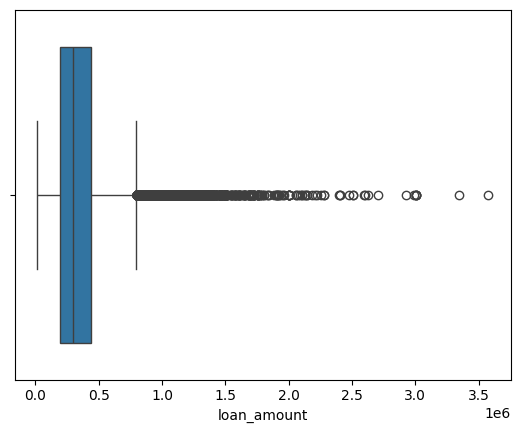

<Figure size 500x300 with 0 Axes>

In [49]:
sns.boxplot(x=df['loan_amount'])
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Presence of large loans (outliers)

### Credit Score

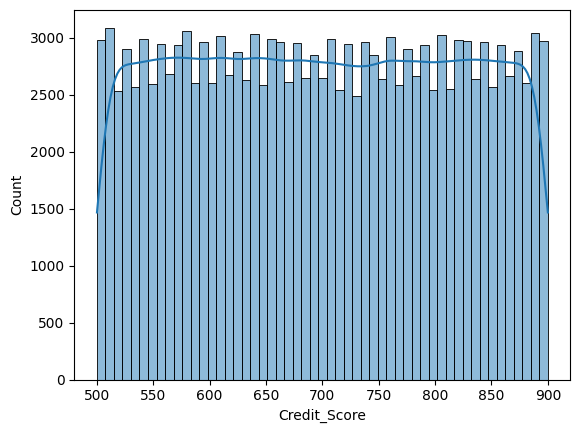

<Figure size 500x300 with 0 Axes>

In [54]:
sns.histplot(df['Credit_Score'], kde=True)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Most customers fall in mid-credit range

## STEP 7: Univariate Analysis (Categorical)

### Loan Purpose

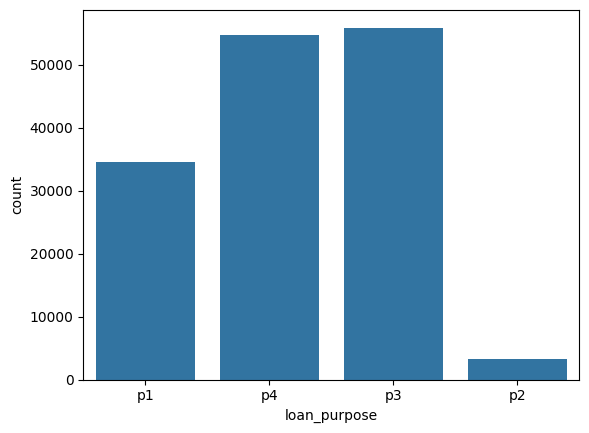

<Figure size 500x300 with 0 Axes>

In [63]:
sns.countplot(x='loan_purpose', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

p3 and p4 loans dominate the portfolio

## STEP 8: Bivariate Analysis (Feature vs Default)

### Income vs Default

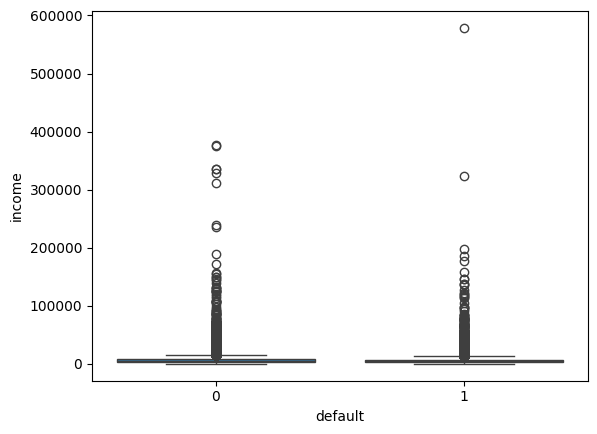

<Figure size 500x300 with 0 Axes>

In [65]:
sns.boxplot(x='default', y='income', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Defaulters generally have lower income

### Loan Amount vs Default

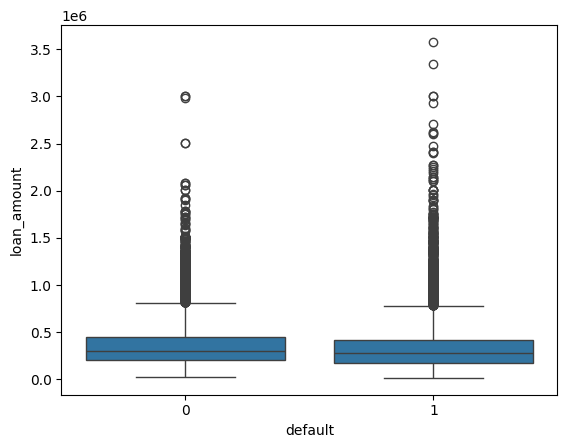

<Figure size 500x300 with 0 Axes>

In [66]:
sns.boxplot(x='default', y='loan_amount', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Larger loans show higher default risk

### Credit Score vs Default

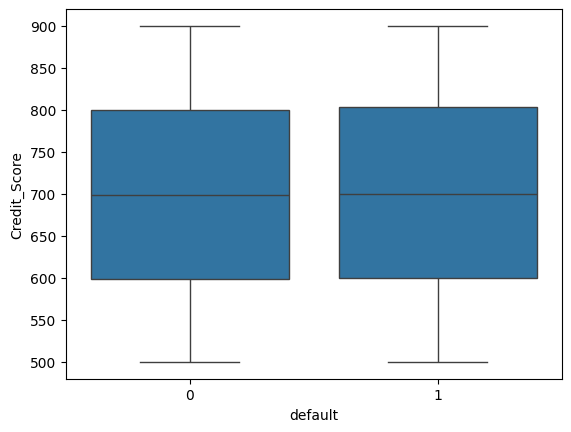

<Figure size 500x300 with 0 Axes>

In [70]:
sns.boxplot(x='default', y='Credit_Score', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Lower credit scores strongly correlate with default

### Loan Purpose vs Default

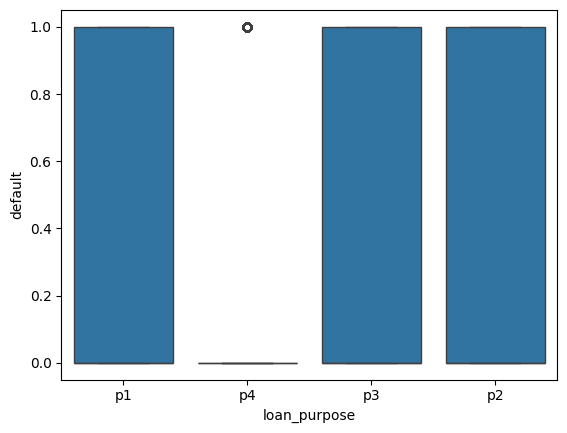

<Figure size 500x300 with 0 Axes>

In [72]:
sns.boxplot(x='loan_purpose', y='default', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

p1, p2 and p3 default more than p4

## STEP 9: Correlation Analysis

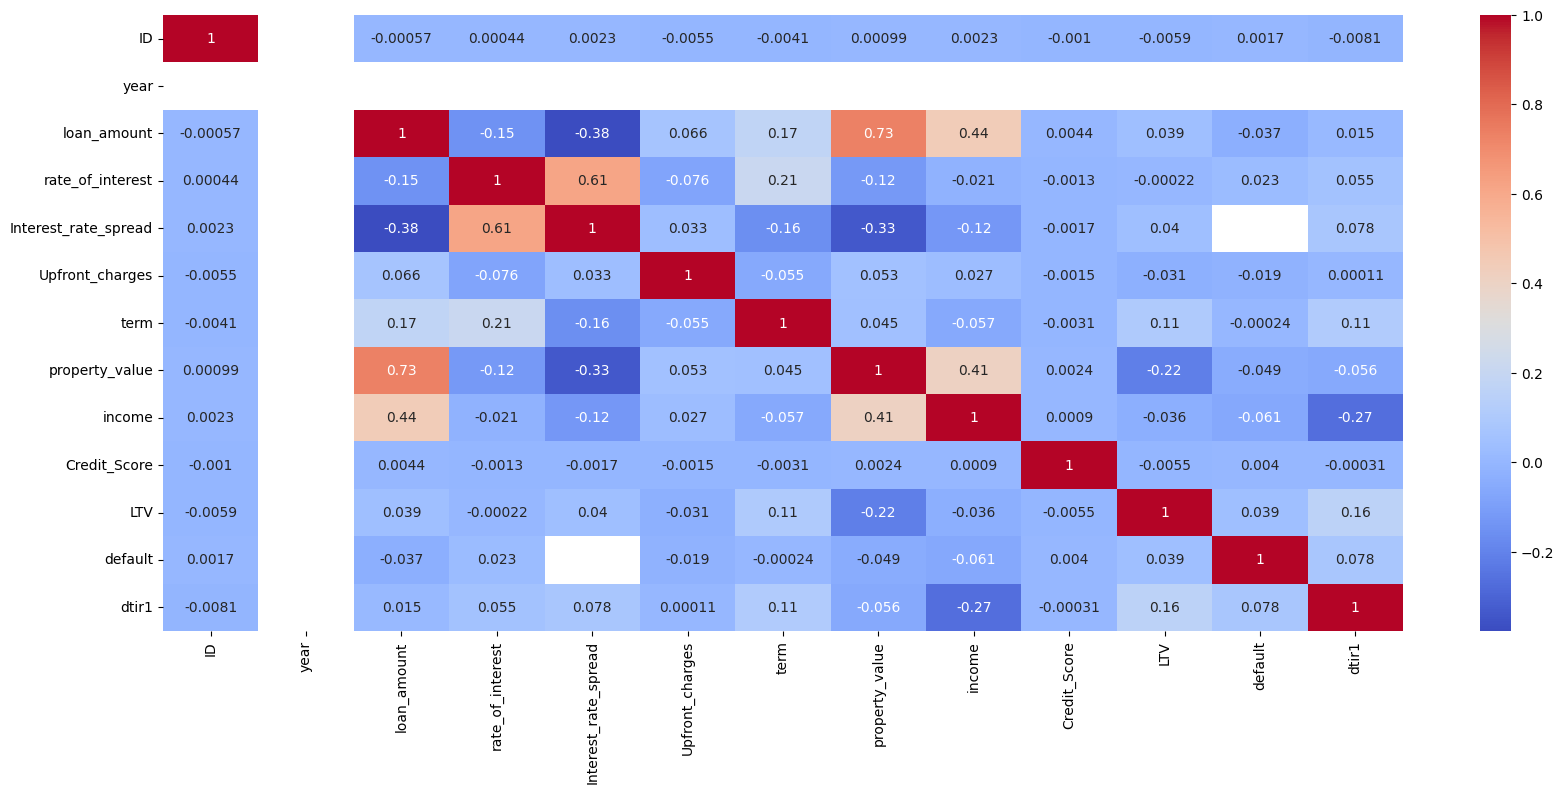

In [79]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

📌 Key Observations

Credit score ↔ default

Loan amount ↔ income 

## STEP 10: Outlier Detection (IQR)

In [84]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

📌 Business Decision

High income outliers are valid → do NOT remove blindly

## STEP 11: Multivariate Insight

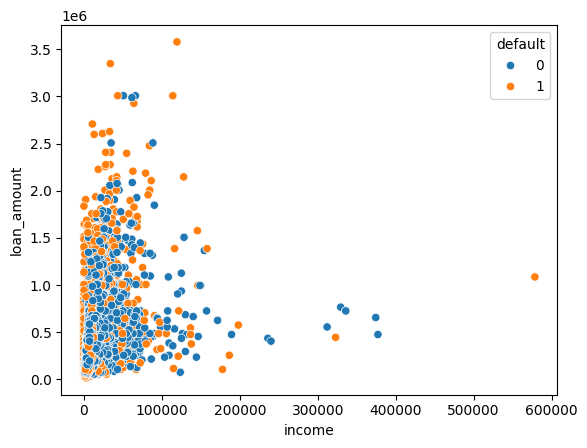

<Figure size 500x300 with 0 Axes>

In [86]:
sns.scatterplot(x='income', y='loan_amount', hue='default', data=df)
plt.figure(figsize=(5,3))
plt.show()

📌 Insight:

Low income + high loan amount → default cluster

## STEP 12: EDA Summary

1. Default rate is low → imbalanced dataset
2. Lower income customers default more
3. Credit score is the strongest risk indicator
4. Larger loans increase default probability
5. Loan purpose impacts default risk
